<a href="https://colab.research.google.com/github/Rishsing73/rishsing73.github.io/blob/master/Perceptron_multiclass_for_NumerAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas sklearn numerapi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Conv1D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras.initializers import RandomNormal



In [ ]:
tour_datalink = 'https://numerai-public-datasets.s3-us-west-2.amazonaws.com/latest_numerai_tournament_data.csv.xz'
train_datalink = 'https://numerai-public-datasets.s3-us-west-2.amazonaws.com/latest_numerai_training_data.csv.xz'
df_train = pd.read_csv(train_datalink, ) #download the training data and keep only the first 50,000 rows
df_tour = pd.read_csv(tour_datalink, )

In [ ]:
features = [c for c in df_train if c.startswith("feature")]
X_train =df_train[features].values
Y_train = df_train['target'].values
test = df_tour[df_tour.data_type == 'validation'].copy()
X_test = test[features].values
Y_test = test['target'].values
X_test.shape

(137779, 310)

In [ ]:

def one_hot(Y_train_):
 Y_tr = np.zeros((len(Y_train_),5))
 for i in range(len(Y_train_)):
  if Y_train_[i] == 0.25:
    Y_tr[i,1] = 1.0
  elif Y_train_[i] == 0.:
    Y_tr[i,0] = 1.0
  elif Y_train_[i] == 0.5:
    Y_tr[i,2] = 1.0
  elif Y_train_[i] == 0.75:
    Y_tr[i,3] = 1.0
  elif Y_train_[i] == 1.:
    Y_tr[i,4] = 1.0
 return(Y_tr)

In [ ]:
  Y_train_enco = one_hot(Y_train)
  Y_test_enco = one_hot(Y_test)
Y_train_enco

array([[0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.]])

Let's Design The Architecture

In [ ]:
model = Sequential([
                    Dense(units= 150, input_shape = (310,), activation='relu',kernel_initializer= 'RandomNormal' ),
                    Dense(units= 75,  activation='relu' ),
                    Dense(units= 30, activation='relu' ),
                    Dense(units= 16, activation='relu' ),
                    Dense(units= 5, activation='softmax' )
])


In [ ]:
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 150)               46650     
_________________________________________________________________
dense_1 (Dense)              (None, 75)                11325     
_________________________________________________________________
dense_2 (Dense)              (None, 30)                2280      
_________________________________________________________________
dense_3 (Dense)              (None, 16)                496       
_________________________________________________________________
dense_4 (Dense)              (None, 5)                 85        
Total params: 60,836
Trainable params: 60,836
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001)
                             , loss='categorical_crossentropy', metrics = ['categorical_accuracy'])

In [ ]:
histor = model.fit(x=X_train,y=Y_train_enco, batch_size= 100, epochs= 100, shuffle= True, verbose=2, validation_data=(X_test,Y_test_enco))

Epoch 1/100
5019/5019 - 12s - loss: 1.2295 - categorical_accuracy: 0.5019 - val_loss: 1.2341 - val_categorical_accuracy: 0.5002
Epoch 2/100
5019/5019 - 11s - loss: 1.2292 - categorical_accuracy: 0.5018 - val_loss: 1.2334 - val_categorical_accuracy: 0.5003
Epoch 3/100
5019/5019 - 11s - loss: 1.2290 - categorical_accuracy: 0.5019 - val_loss: 1.2337 - val_categorical_accuracy: 0.5003
Epoch 4/100
5019/5019 - 11s - loss: 1.2287 - categorical_accuracy: 0.5021 - val_loss: 1.2353 - val_categorical_accuracy: 0.5001
Epoch 5/100
5019/5019 - 11s - loss: 1.2284 - categorical_accuracy: 0.5021 - val_loss: 1.2356 - val_categorical_accuracy: 0.5005
Epoch 6/100
5019/5019 - 11s - loss: 1.2281 - categorical_accuracy: 0.5020 - val_loss: 1.2357 - val_categorical_accuracy: 0.5004
Epoch 7/100
5019/5019 - 12s - loss: 1.2279 - categorical_accuracy: 0.5020 - val_loss: 1.2335 - val_categorical_accuracy: 0.5003
Epoch 8/100
5019/5019 - 12s - loss: 1.2277 - categorical_accuracy: 0.5021 - val_loss: 1.2360 - val_categ

In [ ]:
Y = model.predict(X_test)

In [ ]:
Y



array([[0.04665725, 0.20293863, 0.51277524, 0.20526183, 0.03236707],
       [0.14059883, 0.21648453, 0.30604568, 0.20826557, 0.12860541],
       [0.13355955, 0.20019972, 0.30699173, 0.22192378, 0.13732518],
       ...,
       [0.00373111, 0.13792253, 0.6653673 , 0.18378942, 0.00918973],
       [0.02499683, 0.25318697, 0.52212226, 0.17641681, 0.02327715],
       [0.00828701, 0.15042976, 0.61964464, 0.20605443, 0.01558413]],
      dtype=float32)

In [ ]:
Y = np.argmax(Y,axis = -1)

In [ ]:
Y

array([2, 2, 2, ..., 2, 2, 2])

In [ ]:
def one_inv(Y_train_):
 Y_tr = np.zeros((len(Y_train_)))
 for i in range(len(Y_train_)):
  if Y_train_[i] == 0:
    Y_tr[i] = 0.0
  elif Y_train_[i] == 1.:
    Y_tr[i] = 0.25
  elif Y_train_[i] == 2:
    Y_tr[i] = 0.5
  elif Y_train_[i] == 3:
    Y_tr[i] = 0.75
  elif Y_train_[i] == 4.:
    Y_tr[i] = 1.0
 return(Y_tr)

In [ ]:
Y_ = one_inv(Y)

In [ ]:
Y_

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

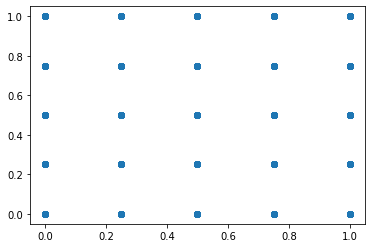

In [ ]:
plt.scatter(Y_,Y_test)

In [ ]:
np.c6orrcoef(Y_,Y_test)

array([[1.        , 0.00408887],
       [0.00408887, 1.        ]])